<a href="https://colab.research.google.com/github/Miller76lite/GEOL558/blob/main/Regression_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#Dataset Review
###Facies logs from nine wells from the Council Grove gas reservoir located in Kansas
###Facies are studied from core samples in every half foot and matched with logging data in well location. Feature variables include five from wireline log measurements and two geologic constraining variables that are derived from geologic knowledge. For more detail refer here

###The seven variables are:

#####GR: this wireline logging tools measure gamma emission
#####ILD_log10: this is resistivity measurement
#####PE: photoelectric effect log
#####DeltaPHI: Phi is a porosity index in petrophysics.
#####PNHIND: Average of neutron and density log.
#####NM_M:nonmarine-marine indicator
#####RELPOS: relative position
###The nine discrete facies (classes of rocks) are:

#####SS: Nonmarine sandstone
#####CSiS: Nonmarine coarse siltstone
#####FSiS: Nonmarine fine siltstone
#####SiSH: Marine siltstone and shale
#####MS: Mudstone (limestone)
#####WS: Wackestone (limestone)
#####D: Dolomite
#####PS: Packstone-grainstone (limestone)
#####BS: Phylloid-algal bafflestone (limestone)

###Using this data, I would like to see if we can we predict the photoelectric effect (PE) of a rock sample based on its other measured properties, such as GR, ILD_log10, and porosity (DeltaPHI or PHIND).




In [2]:
!pip install seaborn==0.13.2

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import tensorflow as tf
from tensorflow import keras
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV

In [4]:
Data = pd.read_csv('https://raw.githubusercontent.com/Miller76lite/GEOL558/main/facies_data.csv')

In [5]:
Data.shape

(3232, 11)

In [6]:
Data.describe()

,Facies,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
count,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000
mean,4.422030,2875.824567,66.135769,0.642719,3.559642,13.483213,3.725014,1.498453,0.520287
std,2.504243,131.006274,30.854826,0.241845,5.228948,7.698980,0.896152,0.500075,0.286792
min,1.000000,2573.500000,13.250000,-0.025949,-21.832000,0.550000,0.200000,1.000000,0.010000
25%,2.000000,2791.000000,46.918750,0.492750,1.163750,8.346750,3.100000,1.000000,0.273000
50%,4.000000,2893.500000,65.721500,0.624437,3.500000,12.150000,3.551500,1.000000,0.526000
75%,6.000000,2980.000000,79.626250,0.812735,6.432500,16.453750,4.300000,2.000000,0.767250
max,9.000000,3122.500000,361.150000,1.480000,18.600000,84.400000,8.094000,2.000000,1.000000


In [7]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Facies     3232 non-null   int64  
 1   Formation  3232 non-null   object 
 2   Well Name  3232 non-null   object 
 3   Depth      3232 non-null   float64
 4   GR         3232 non-null   float64
 5   ILD_log10  3232 non-null   float64
 6   DeltaPHI   3232 non-null   float64
 7   PHIND      3232 non-null   float64
 8   PE         3232 non-null   float64
 9   NM_M       3232 non-null   int64  
 10  RELPOS     3232 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 277.9+ KB


As we can see from the data information, we have 3232 entries with no missing data. We will clean the data of un wanted variables and outliers below.

###Removing Unneeded Data:
#####Irrelevant or redundant data can hinder model performance and interpretability. By selectively removing features that are not directly related to the target variable or the chosen predictors, we can streamline the analysis and improve model efficiency. This ensures that the model focuses on the most relevant information for making predictions. Below we will remove the columns labled Facies, Formation, Well Name, and Depth.

In [8]:
data_cleaned = Data.drop(columns=['Facies', 'Formation', 'Well Name', 'Depth'])

# Print the cleaned data's information
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GR         3232 non-null   float64
 1   ILD_log10  3232 non-null   float64
 2   DeltaPHI   3232 non-null   float64
 3   PHIND      3232 non-null   float64
 4   PE         3232 non-null   float64
 5   NM_M       3232 non-null   int64  
 6   RELPOS     3232 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 176.9 KB


###Handling Missing Values:
#####Missing data is a common issue in datasets and can lead to biased results if not addressed properly. Imputation techniques, such as replacing missing values with the mean or median, can help preserve information and ensure model compatibility. Alternatively, rows or columns with excessive missing data may be removed, but with careful consideration of potential information loss.

In [9]:
imputer = SimpleImputer(strategy='mean')  # Replace with 'median' or other strategy if needed
numerical_features = data_cleaned.select_dtypes(include=np.number).columns
data_cleaned[numerical_features] = imputer.fit_transform(data_cleaned[numerical_features])

# Print the updated data's information
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GR         3232 non-null   float64
 1   ILD_log10  3232 non-null   float64
 2   DeltaPHI   3232 non-null   float64
 3   PHIND      3232 non-null   float64
 4   PE         3232 non-null   float64
 5   NM_M       3232 non-null   float64
 6   RELPOS     3232 non-null   float64
dtypes: float64(7)
memory usage: 176.9 KB


###Outlier Detection:
#####Outliers, or extreme data points, can significantly influence model training and lead to inaccurate predictions. Identifying and handling outliers is essential for building robust models. This may involve removing outliers, transforming the data to reduce their impact, or using algorithms less sensitive to extreme values. Careful investigation of the nature and cause of outliers is crucial before taking any action.

In [10]:
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

# Apply to numerical features
numerical_features = data_cleaned.select_dtypes(include=np.number).columns
for feature in numerical_features:
    data_cleaned = handle_outliers_iqr(data_cleaned, feature)

# Print the updated data's information
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GR         3232 non-null   float64
 1   ILD_log10  3232 non-null   float64
 2   DeltaPHI   3232 non-null   float64
 3   PHIND      3232 non-null   float64
 4   PE         3232 non-null   float64
 5   NM_M       3232 non-null   float64
 6   RELPOS     3232 non-null   float64
dtypes: float64(7)
memory usage: 176.9 KB


###Redundant Feature Removal:
#####Highly correlated features can introduce multicollinearity, which can destabilize model training and hinder interpretation. By removing redundant features, we can simplify the model, improve interpretability, and avoid potential issues with overfitting. Correlation analysis and feature selection techniques can help identify and remove redundant features while retaining the most informative ones.

In [11]:
# Calculate correlation matrix
correlation_matrix = data_cleaned[numerical_features].corr()

# Set threshold for correlation
threshold = 0.95

# Find highly correlated features
highly_correlated = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            highly_correlated.add(colname)

# Remove highly correlated features
data_cleaned = data_cleaned.drop(columns=highly_correlated)

# Print the cleaned data's information
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GR         3232 non-null   float64
 1   ILD_log10  3232 non-null   float64
 2   DeltaPHI   3232 non-null   float64
 3   PHIND      3232 non-null   float64
 4   PE         3232 non-null   float64
 5   NM_M       3232 non-null   float64
 6   RELPOS     3232 non-null   float64
dtypes: float64(7)
memory usage: 176.9 KB


###Pair plots of each Compound

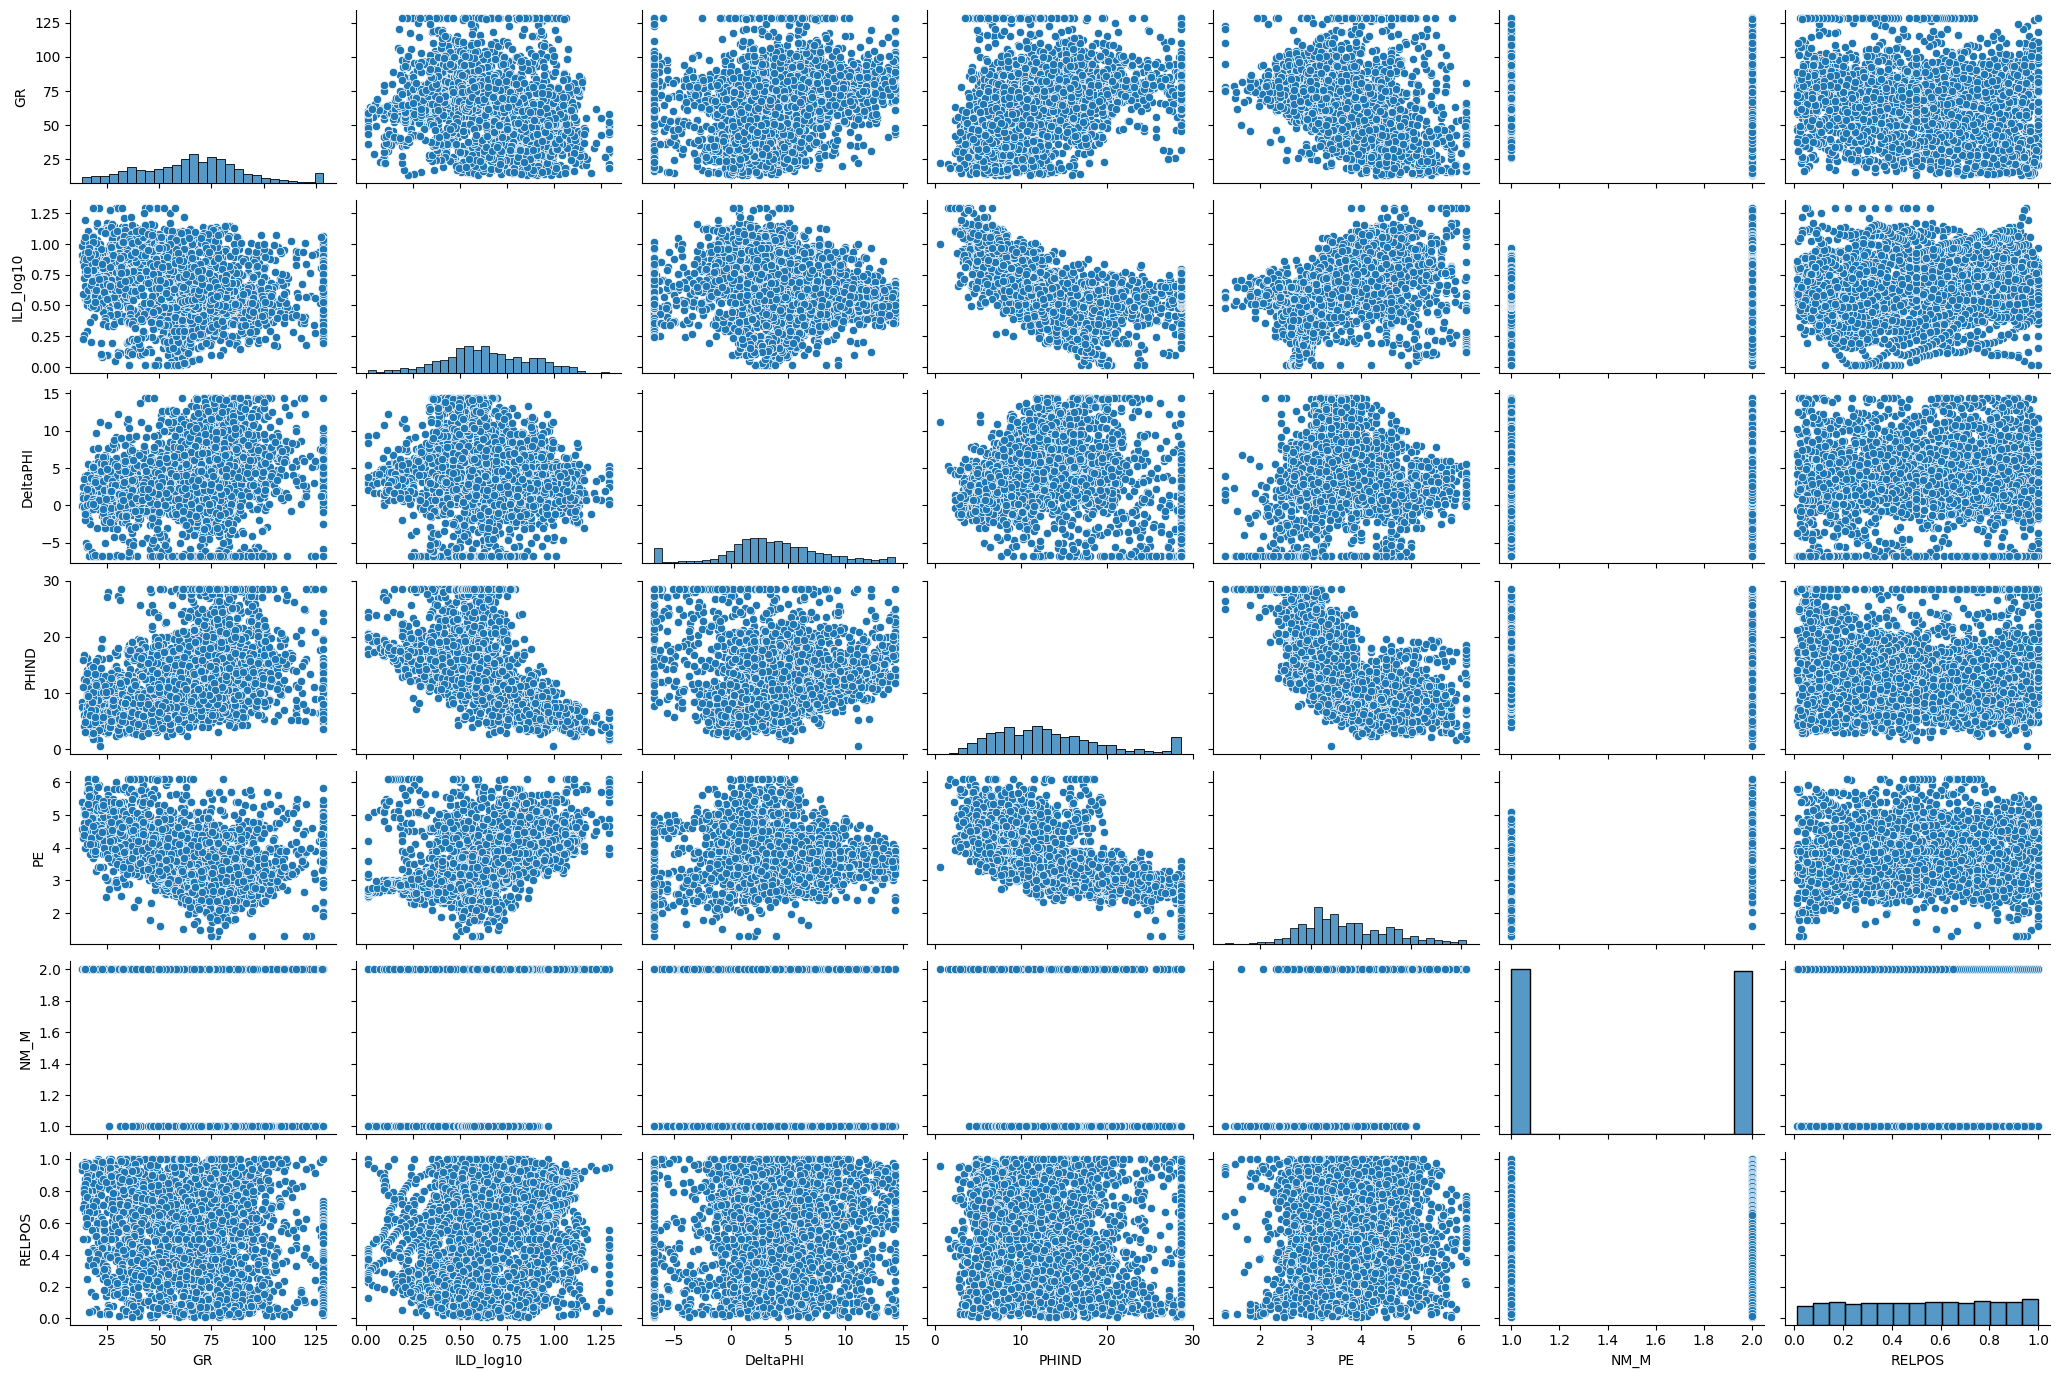

In [12]:
numeric_columns = data_cleaned.select_dtypes(include='number').columns
sns.pairplot(data_cleaned[numeric_columns], height=2, aspect=1.5)  # Adjust height and aspect as needed
plt.show()

In [13]:
correlation_matrix = data_cleaned.corr(numeric_only=True)

###Correlation Heat Map

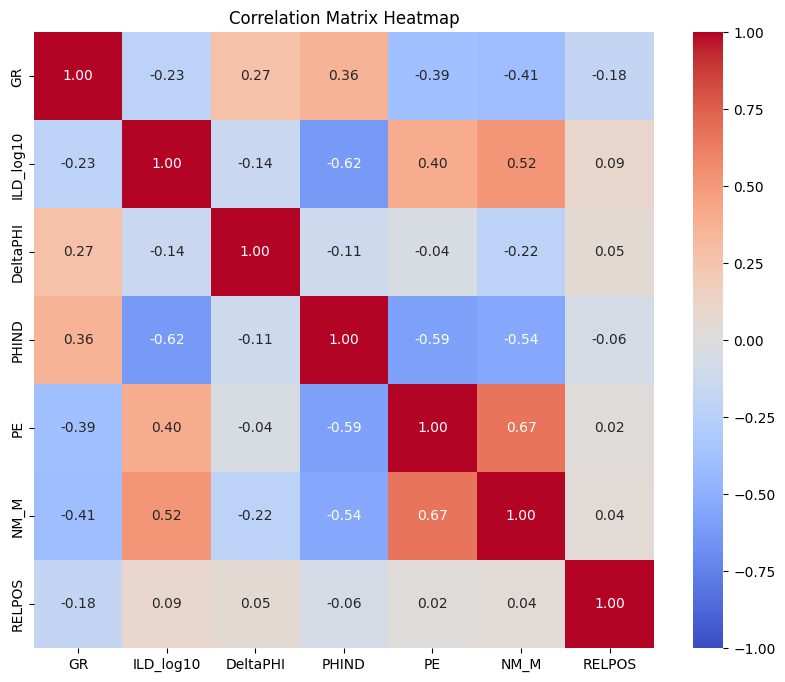

In [21]:
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)  # Set vmin and vmax)
plt.title("Correlation Matrix Heatmap")
plt.show()

### ECDF Plots

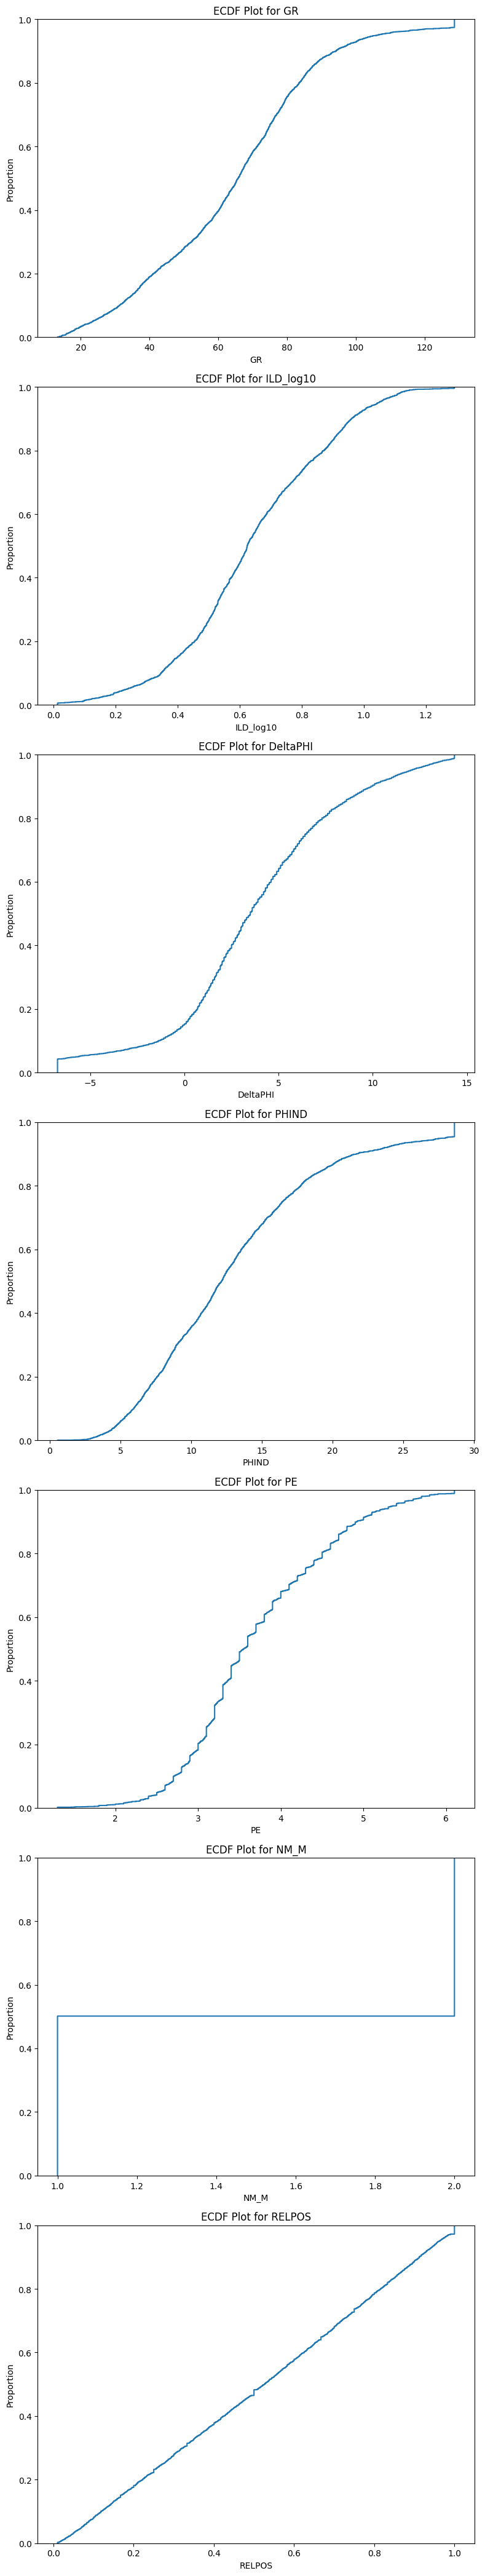

In [15]:
numeric_columns = data_cleaned.select_dtypes(include='number').columns
# Create ECDF plots for all numerical variables
fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(8, 6 * len(numeric_columns))) # Create subplots

for i, column in enumerate(numeric_columns):
    sns.ecdfplot(data=data_cleaned, x=column, ax=axes[i])  # Plot ECDF on the subplot
    axes[i].set_title(f"ECDF Plot for {column}")  # Set title for each subplot

plt.tight_layout()  # Adjust subplot spacing to prevent overlap
plt.show()

As we can see from the EDA, there are not many visible correlations in the pair plots. This is further confirmed by the correlation heat map. The CDF plots show that some of the variables are normally distributed, while others are concentrated.

###Support Vector Regression (SVR):
#####SVR is a powerful machine learning model used for regression tasks. It aims to find the best-fitting hyperplane that maximizes the margin between the hyperplane and the data points while minimizing prediction errors. In this code, SVR is applied to predict the photoelectric effect (PE) of rock samples based on features like GR, ILD_log10, and DeltaPHI. SVR is particularly useful for complex datasets where linear models may not perform well. It can handle non-linear relationships and is robust to outliers. By using GridSearchCV to optimize its hyperparameters, we ensure that SVR delivers its best possible performance on the data.
#####The first SVR model does not include hyperparameters, but the second graph does. This is to compare how well the hyperparameter tuning affects the outcome.

Mean Squared Error: 0.4089467856898608
R-squared: 0.49216963490709864


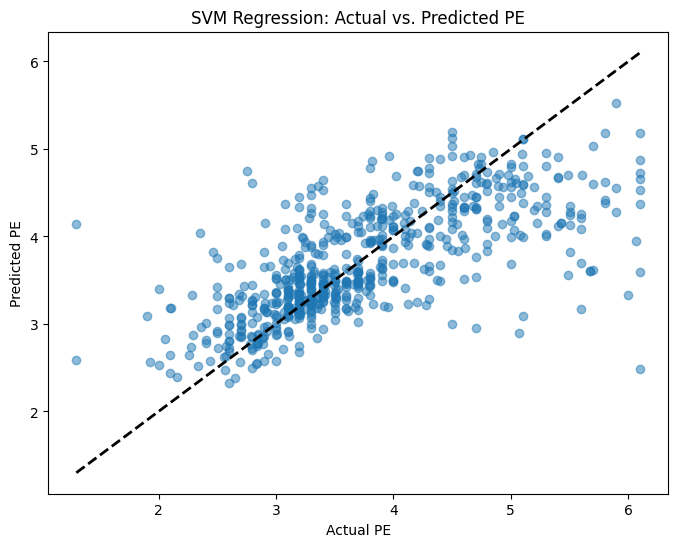

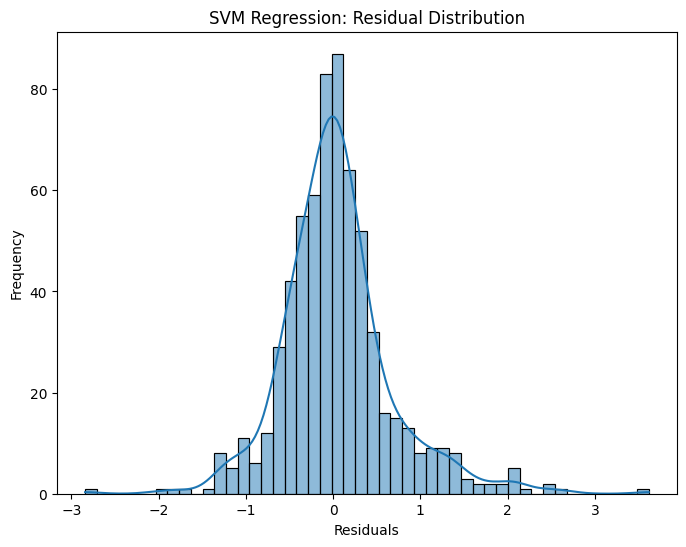

In [16]:
# Split data into training and testing sets
X = data_cleaned[['GR', 'ILD_log10', 'DeltaPHI']]
y = data_cleaned['PE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train the model
model = SVR(kernel='rbf')  # You can experiment with different kernels
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Visualizations
# Scatter plot (Actual vs. Predicted)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("SVM Regression: Actual vs. Predicted PE")
plt.show()

# Residual plot
plt.figure(figsize=(8, 6))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("SVM Regression: Residual Distribution")
plt.show()

#####Hyperparameter

In [17]:

# Define the parameter grid
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1],
    'epsilon': [0.1, 0.2, 0.3]  # Add epsilon for SVR
}

# Create and train the model with GridSearchCV
grid_search = GridSearchCV(SVR(), param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

# Get the best model and its parameters
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Make predictions and evaluate
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Best Hyperparameters: {'C': 1, 'epsilon': 0.3, 'gamma': 1, 'kernel': 'rbf'}
Mean Squared Error: 0.3686370325650228
R-squared: 0.5422263106470953


##### Graph with hyperparameter tuning

Mean Squared Error: 0.3841290816661808
R-squared: 0.5229882747304986


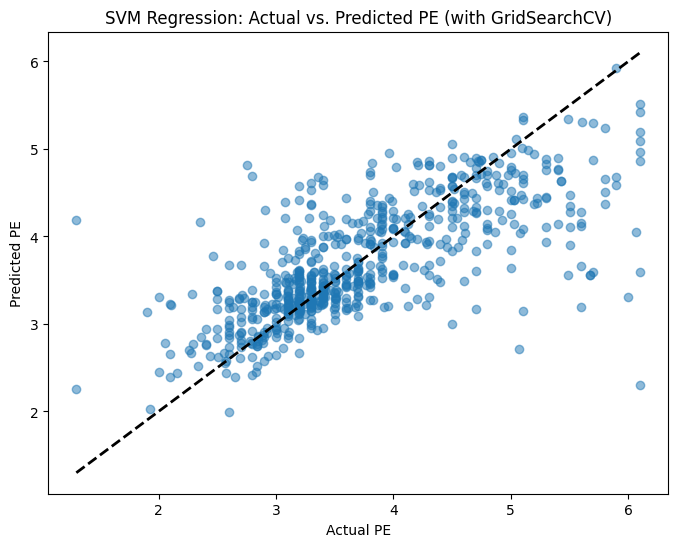

In [18]:
# Use the best hyperparameters from GridSearchCV
best_params = {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'} # Replace with your best parameters from GridSearchCV output

# Create and train the model with best parameters
model = SVR(**best_params)  # Create the model with best hyperparameters
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("SVM Regression: Actual vs. Predicted PE (with GridSearchCV)")
plt.show()

###Decision Tree Regression:
#####Decision trees are another valuable tool for regression. They work by recursively partitioning the data based on feature values, creating a tree-like structure where each leaf node represents a prediction. this code uses a decision tree to predict PE based on the same features as SVR. Decision trees are intuitive and easy to interpret, allowing you to visualize the decision-making process. They are also capable of capturing non-linear relationships and interactions between features. While decision trees can sometimes be prone to overfitting, this ccould be mitigated by adjusting their complexity.

Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mean Absolute Error: 0.4608246374061701
Mean Squared Error: 0.39783914769713696
R-squared: 0.5059631064651381


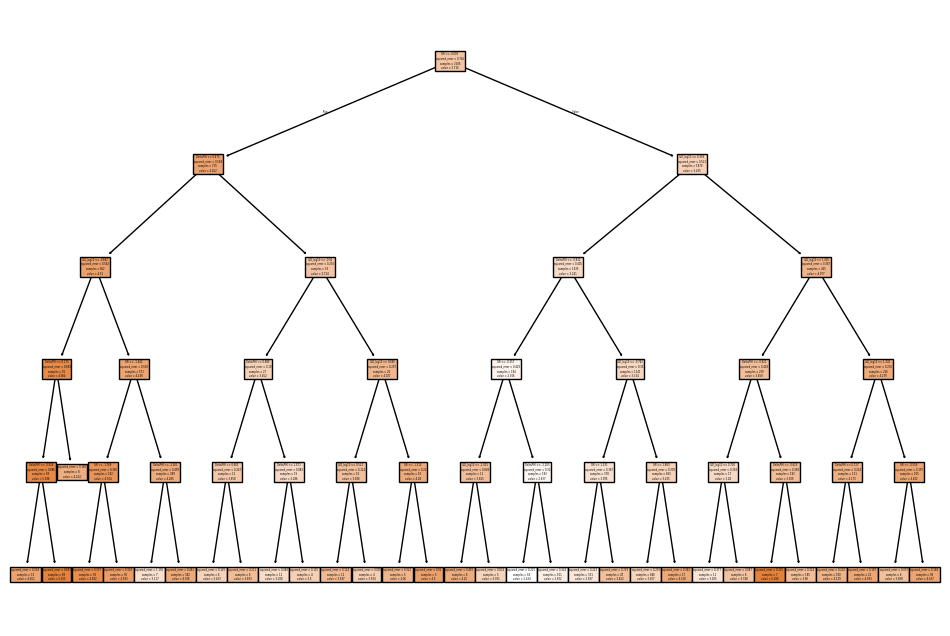

In [26]:
# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create and train the model with GridSearchCV
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

# Get the best model and its parameters
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Make predictions using the best model
y_pred = best_model.predict(X_test)

# Evaluate the model (replace 'model' with 'best_model' if needed)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
plt.figure(figsize=(12, 8))
# Pass 'best_model' (DecisionTreeRegressor) to plot_tree instead of 'model' (Sequential)
plot_tree(best_model, feature_names=X.columns, filled=True)
plt.show()

###Neural Network Regression:
#####Neural networks are sophisticated models inspired by the structure of the human brain. They consist of interconnected layers of nodes (neurons) that process information to make predictions. This code implements a simple neural network with two hidden layers to predict PE. Neural networks are known for their ability to learn complex patterns and relationships in data. They can handle a wide range of regression tasks, including those with high dimensionality and non-linearity. This is useful because it can capture complex patterns and relationships in the data that simpler models might miss. It has the potential to provide highly accurate predictions of PE if properly trained and tuned.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Mean Absolute Error: 0.4480021474740973
Mean Squared Error: 0.39196288287728215
R-squared: 0.5132602556622284


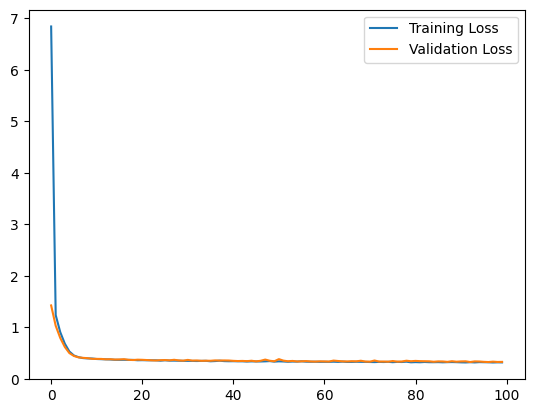

In [28]:
# Define the model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0)  # Adjust epochs as needed

# Make predictions and evaluate
y_pred = model.predict(X_test).flatten()  # Flatten to match y_test shape
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

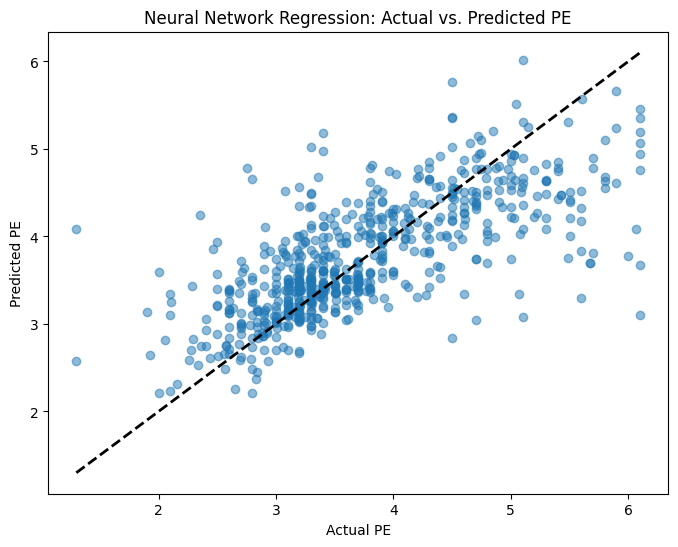

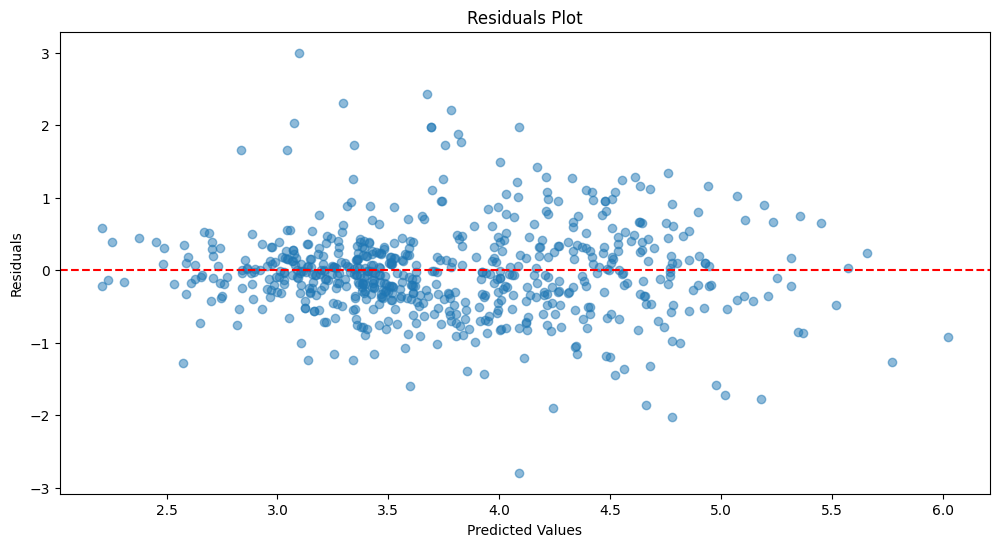

In [29]:
# Predicted vs. Actuals plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("Neural Network Regression: Actual vs. Predicted PE")
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(12, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

## Which method did I like the most?
#### The method I liked the most was the SVM model. This is because it provided a good visualization of the data and has the benefit of also showing the hyperparameter tuning. This makes it easy to see how that method affects the model.

##Which method did I like the Least?
####The method I liked the least was the neural network.

## How did you score these supervised models?
####The supervised models in the notebook were evaluated using Mean Squared Error, R-squared, and Mean Absolute Error to assess their accuracy and predictive capability.

## Did the output align with your geologic understanding?
#### This did align with my original understanding of well log data. Trying to predict PR using GR, ILD_log10, and porosity seemed like it would be a difficult task, and the scoring does show that it would be a 50/50 success rate. I knew it would be difficult, but the prediction capabilities were lower than I expected.

##What did you want to learn more about?
#### I would personally like to look more into neural networks as I feel there is much more to offer through this method than I have laid out in the notebook.

##Did you pre-process your data?
####The notebook incorporated data pre-processing steps, including handling missing values, outlier detection, redundant feature removal, and data scaling to prepare the data for machine learning. While pre-processing is generally advantageous, the requirements vary depending on the chosen model, the dataset characteristics, and the desired outcome.